1) Реализуйте функцию makeheap_n_log_n(arr), которая преобразует произвольный массив arr в minheap за O(N log N).

2) Реализуйте функцию makeheap(arr), которая преобразует произвольный массив arr в minheap за O(N).

К решению необходимо прикрепить отчет/фото, в котором будет объяснен подход и доказана сложность (необходимо аккуратно выписать сумму).

В финале - сравните время работы двух методов.

### makeheap_n_log_n(arr), которая преобразует произвольный массив arr в minheap за O(N log N)

In [3]:
# Преобразует массив в min-heap за O(N log N)
def makeheap_n_log_n(arr):

    # Просеивание вверх: восстанавливаем свойство min-heap
    def sift_up(arr, idx):
        while idx > 0:
            parent = (idx - 1) // 2
            if arr[idx] >= arr[parent]:
                break
            arr[idx], arr[parent] = arr[parent], arr[idx]
            idx = parent
        
    if not arr:
        return arr
    n = len(arr)
    # Для каждого элемента начиная со второго просеиваем вверх
    for i in range(1, n):
        sift_up(arr, i)
    
    return arr

Доказательство сложности O(N log N): 

Операция просеивания вверх занимает O(log N) в худшем случае (высота дерева)

Всего N элементов => общая сложность: N * O(log N) = O(N log N)

### makeheap(arr), которая преобразует произвольный массив arr в minheap за O(N)

In [6]:
# Преобразует массив в min-heap за O(N)
def makeheap(arr):

    # Просеивание вниз: восстанавливаем свойство min-heap
    def sift_down(arr, idx, heap_size):
        while True:
            smallest = idx
            left = 2 * idx + 1
            right = 2 * idx + 2
            
            if left < heap_size and arr[left] < arr[smallest]:
                smallest = left
            if right < heap_size and arr[right] < arr[smallest]:
                smallest = right
            if smallest == idx:
                break   
            
            arr[idx], arr[smallest] = arr[smallest], arr[idx]
            idx = smallest
    
    if not arr:
        return arr
    n = len(arr)
    # Начинаем с последнего внутреннего узла
    for i in range(n//2 - 1, -1, -1):
        sift_down(arr, i, n)
    
    return arr

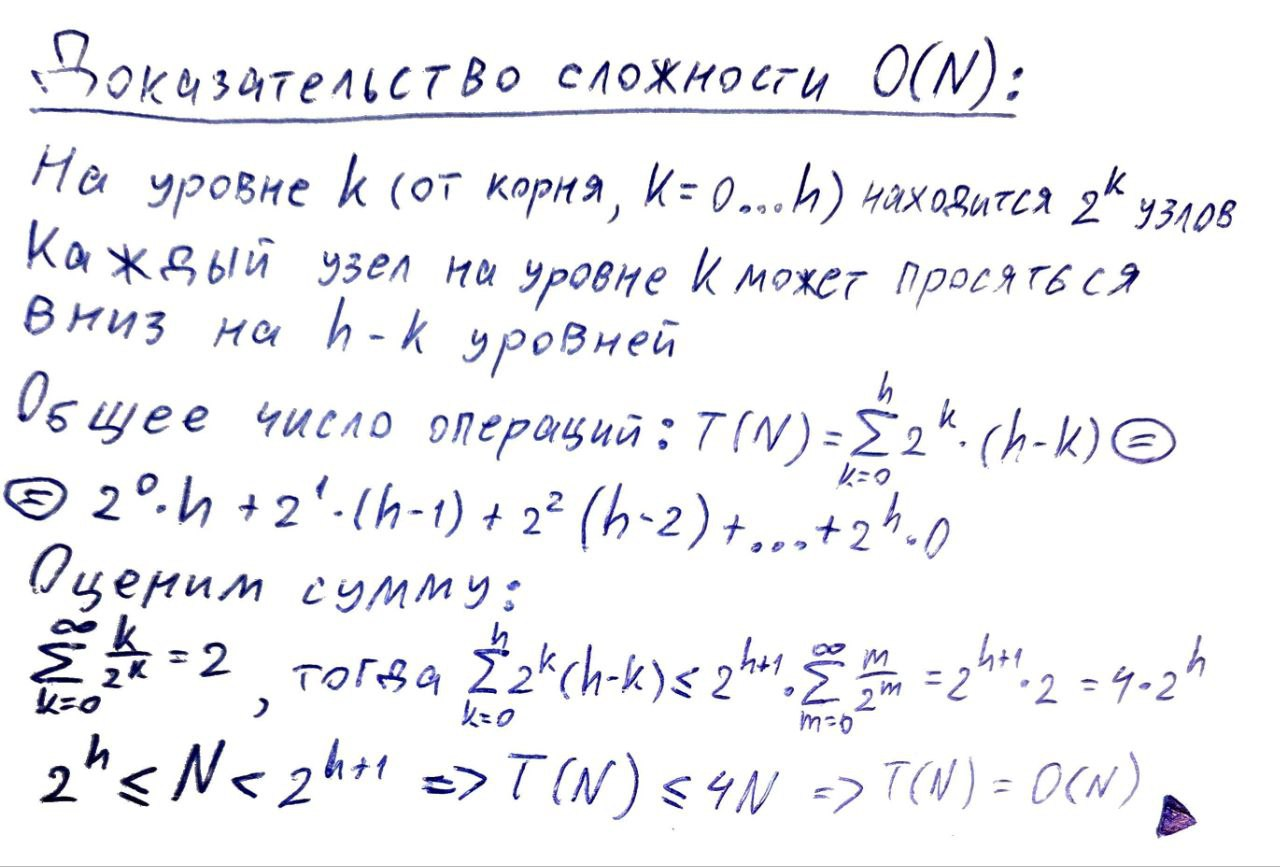

### Сравнение времени работы методов

In [46]:
import time
import random

def benchmark(func, arr):
    start = time.time()
    func(arr.copy())
    return time.time() - start

sizes = [100000, 500000, 1000000, 5000000]
for n in sizes:
    arr = [random.randint(1, 1000) for _ in range(n)]
    t1 = benchmark(makeheap_n_log_n, arr)
    t2 = benchmark(makeheap, arr)
    print(f"N={n}: O(N log N)={t1:.4f}с, O(N)={t2:.4f}с")

N=100000: O(N log N)=0.0638с, O(N)=0.0778с
N=500000: O(N log N)=0.3311с, O(N)=0.3676с
N=1000000: O(N log N)=0.7914с, O(N)=0.6838с
N=5000000: O(N log N)=3.3808с, O(N)=3.4957с


### Тесты

In [49]:
# Проверяет, является ли массив min-heap
def is_min_heap(arr):
    n = len(arr)
    for i in range(n):
        left = 2 * i + 1
        right = 2 * i + 2
        if left < n and arr[left] < arr[i]:
            return False
        if right < n and arr[right] < arr[i]:
            return False
    return True

test_arrays = [
    [4, 10, 3, 5, 1],
    [1],
    [],
    [5, 4, 3, 2, 1],
    [1, 2, 3, 4, 5]
]

for arr in test_arrays:
    arr1 = arr.copy()
    arr2 = arr.copy()
    
    makeheap_n_log_n(arr1)
    makeheap(arr2)
    
    assert is_min_heap(arr1), f"Ошибка в makeheap_n_log_n: {arr1}"
    assert is_min_heap(arr2), f"Ошибка в makeheap: {arr2}"
    print(f"OK: {arr} → {arr1} (O(N log N)), {arr2} (O(N))")

OK: [4, 10, 3, 5, 1] → [1, 3, 4, 10, 5] (O(N log N)), [1, 4, 3, 5, 10] (O(N))
OK: [1] → [1] (O(N log N)), [1] (O(N))
OK: [] → [] (O(N log N)), [] (O(N))
OK: [5, 4, 3, 2, 1] → [1, 2, 4, 5, 3] (O(N log N)), [1, 2, 3, 5, 4] (O(N))
OK: [1, 2, 3, 4, 5] → [1, 2, 3, 4, 5] (O(N log N)), [1, 2, 3, 4, 5] (O(N))
